<a href="https://colab.research.google.com/github/RichaGaharwar/Walmart---Confidence-Interval-CLT/blob/main/Walmart_Confidence_Interval_%26_CLT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **About Walmart**
---
Walmart is an American multinational retail corporation that operates a chain of supercenters, discount departmental stores, and grocery stores from the United States. Walmart has more than 100 million customers worldwide.

---
**Business Problem**

---

The Management team at Walmart Inc. wants to analyze the customer purchase behavior (specifically, purchase amount) against the customer’s gender and the various other factors to help the business make better decisions. They want to understand if the spending habits differ between male and female customers: Do women spend more on Black Friday than men? (Assume 50 million customers are male and 50 million are female).

---
**Dataset**

---


The company collected the transactional data of customers who purchased products from the Walmart Stores during Black Friday.

The dataset has the following features:

* User_ID:	User ID
* Product_ID:	Product ID
* Gender:	Sex of User
* Age:	Age in bins
* Occupation:	Occupation(Masked)
* City_Category:	Category of the City (A,B,C)
* StayInCurrentCityYears:	Number of years stay in current city
* Marital_Status:	Marital Status
* ProductCategory:	Product Category (Masked)
* Purchase:	Purchase Amount




---

**What good looks like?**

---



* Import the dataset and do usual data analysis steps like checking the structure & characteristics of the dataset.
* Detect Null values & Outliers (using boxplot, “describe” method by checking the difference between mean and median, isnull etc.)
* do some data exploration steps like:

  * Tracking the amount spent per transaction of all the 50 million female customers, and all the 50 million male customers, calculate the average, and conclude the results.
  * Inference after computing the average female and male expenses.
  * Use the sample average to find out an interval within which the population average will lie. Using the sample of female customers you will calculate the interval within which the average spending of 50 million male and female customers may lie.
* Use the Central limit theorem to compute the interval. Change the sample size to observe the distribution of the mean of the expenses by female and male customers.
  * The interval that you calculated is called Confidence Interval. The width of the interval is mostly decided by the business: Typically 90%, 95%, or 99%. Play around with the width parameter and report the observations.
* conclude the results and check if the confidence intervals of average male and female spends are overlapping or not overlapping. How can Walmart leverage this conclusion to make changes or improvements?
* Perform the same activity for Married vs Unmarried and Age
  * For Age, you can try bins based on life stages: 0-17, 18-25, 26-35, 36-50, 51+ years.
* Give recommendations and action items to Walmart.



---


**Evaluation Criteria**


---



* Defining Problem Statement and Analyzing basic metrics (10 Points)
  * Observations on shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required), statistical summary
  * Non-Graphical Analysis: Value counts and unique attributes ​
  * Visual Analysis - Univariate & Bivariate
    * For continuous variable(s): Distplot, countplot, histogram for univariate analysis
    * For categorical variable(s): Boxplot
    * For correlation: Heatmaps, Pairplots
* Missing Value & Outlier Detection (10 Points)
* Business Insights based on Non- Graphical and Visual Analysis (10 Points)
  * Comments on the range of attributes
  * Comments on the distribution of the variables and relationship between them
  * Comments for each univariate and bivariate plot
* Answering questions (50 Points)
  * Are women spending more money per transaction than men? Why or Why not? (10 Points)
  * Confidence intervals and distribution of the mean of the expenses by female and male customers (10 Points)
  * Are confidence intervals of average male and female spending overlapping? How can Walmart leverage this conclusion to make changes or improvements? (10 Points)
  * Results when the same activity is performed for Married vs Unmarried (10 Points)
  * Results when the same activity is performed for Age (10 Points)
* Final Insights (10 Points) - Illustrate the insights based on exploration and CLT
  * Comments on the distribution of the variables and relationship between them
  * Comments for each univariate and bivariate plots
  * Comments on different variables when generalizing it for Population
* Recommendations (10 Points)
  * Actionable items for business. No technical jargon. No complications. Simple action items that everyone can understand

**colors**:
* Spark Yellow : '#FFC220'
* True Blue : '#0071CE'
* White : '#FFFFFF'

---

# **Exploratory Data Analysis**

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

walmart = pd.read_csv('/content/walmart.csv')

In [2]:
walmart.shape

(550068, 10)

In [3]:
walmart.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [4]:
walmart.tail(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365
550067,1006039,P00371644,F,46-50,0,B,4+,1,20,490


We have 10 features and more than 550k records

In [5]:
walmart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


* No missing values found
* change the datatype:
  * occupation
  * product_category
  * marital status

In [6]:
walmart['User_ID'] = walmart['User_ID'].astype(int)
walmart['Occupation'] = walmart['Occupation'].astype(object)
walmart['Product_Category'] = walmart['Product_Category'].astype(object)
walmart['Marital_Status'] = walmart['Marital_Status'].astype(object)

walmart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  object
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  object
 8   Product_Category            550068 non-null  object
 9   Purchase                    550068 non-null  int64 
dtypes: int64(2), object(8)
memory usage: 42.0+ MB


In [7]:
walmart['Purchase'].describe()

,Purchase
count,550068.000000
mean,9263.968713
std,5023.065394
min,12.000000
25%,5823.000000
50%,8047.000000
75%,12054.000000
max,23961.000000


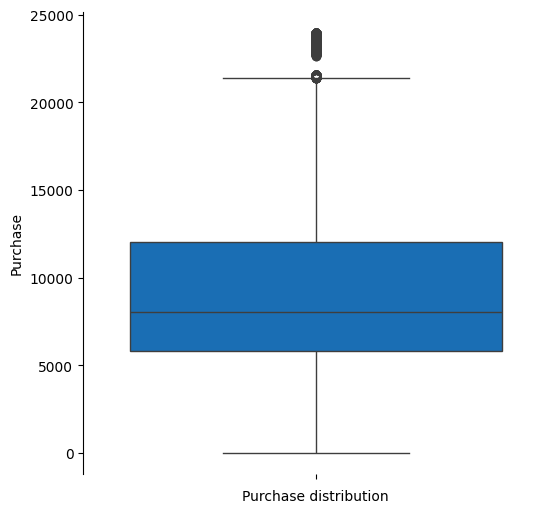

In [8]:
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'

plt.figure(figsize = (6, 6))
ax = plt.gca()
sns.boxplot(walmart['Purchase'], color = True_Blue)
plt.xlabel('Purchase distribution')
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

purchase amount has outliers, ie. there are people making purchases of high amounts.

import scipy.stats as stats
true_blue = '#0073e6'

mu = walmart['Purchase'].mean()
sigma = walmart['Purchase'].std()

x = np.linspace(walmart['Purchase'].min(), walmart['Purchase'].max(), 1000)

y = stats.norm.pdf(x, mu, sigma)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(x, y, color=true_blue, linewidth=2.5)
ax.fill_between(x, y, color=true_blue, alpha=0.1)

plt.xlabel('Purchase Amount')
plt.ylabel('Probability Density')
ax.set_title('Gaussian Curve for Purchase Amount', fontsize=14, pad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

Text(0.5, 1.0, 'Gender Distribution')

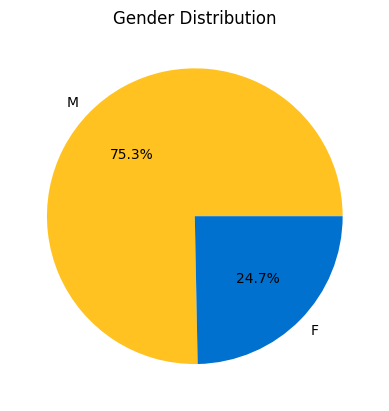

In [9]:
plt.pie(x=walmart['Gender'].value_counts(), labels=walmart['Gender'].value_counts().index, colors=['#FFC220', '#0071CE'], autopct='%1.1f%%')
plt.title('Gender Distribution')

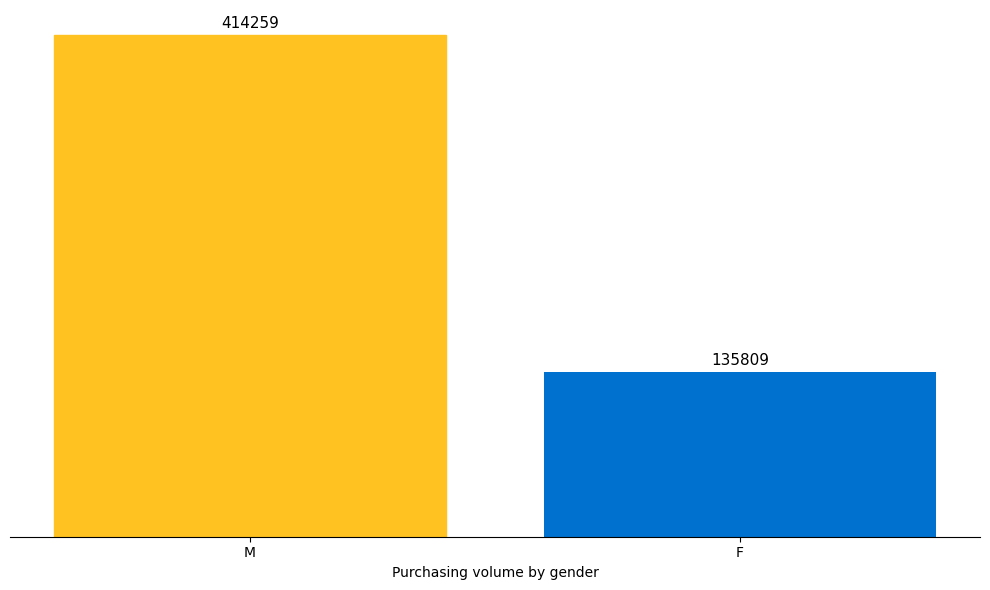

In [10]:
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'

plt.figure(figsize = (10, 6))
ax = plt.gca()
bars = plt.bar(walmart['Gender'].value_counts().index, walmart['Gender'].value_counts().values, color = True_Blue)
ax.get_yaxis().set_visible(False)
ax.bar_label(ax.containers[0], padding=3, fontsize=11)
plt.xlabel('Purchasing volume by gender')
plt.xticks(rotation = 0)

top_1_indices = np.argsort(walmart['Gender'].value_counts().values)[-1:]
for idx in top_1_indices:
    bars[idx].set_color(Spark_Yellow)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

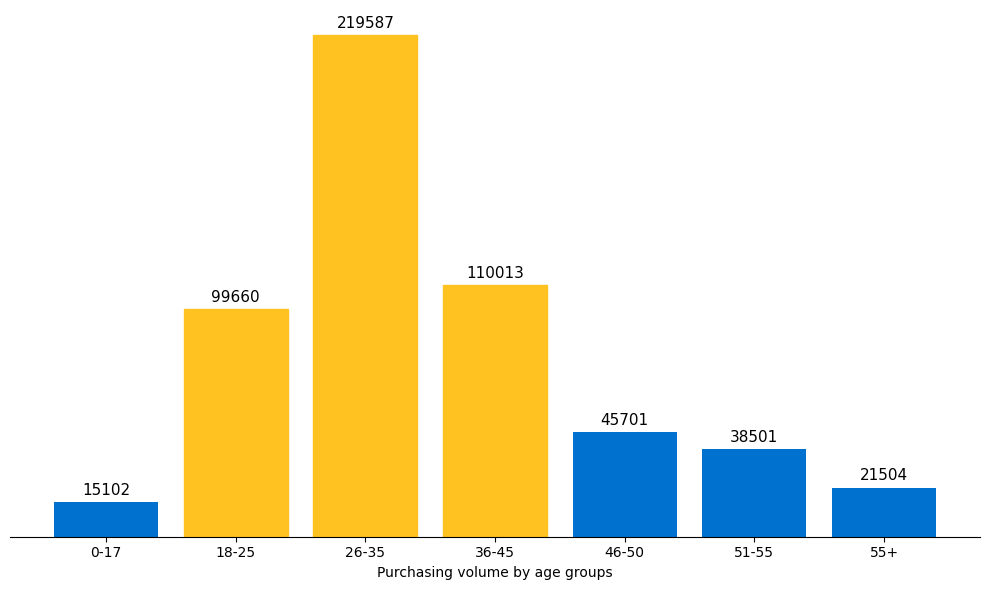

In [11]:
age_counts = walmart['Age'].value_counts().sort_index()

Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'

plt.figure(figsize = (10, 6))
bars = plt.bar(age_counts.index.astype(str), age_counts.values, color=True_Blue)
ax = plt.gca()
ax.get_yaxis().set_visible(False)
ax.bar_label(ax.containers[0], padding=3, fontsize=11)
plt.xlabel('Purchasing volume by age groups')
plt.ylabel('purchase_amount')
plt.xticks(rotation = 0)

top_3_indices = np.argsort(age_counts.values)[-3:]
for idx in top_3_indices:
    bars[idx].set_color(Spark_Yellow)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

In [12]:
walmart['Occupation'].unique()

array([10, 16, 15, 7, 20, 9, 1, 12, 17, 0, 3, 4, 11, 8, 19, 2, 18, 5, 14,
       13, 6], dtype=object)

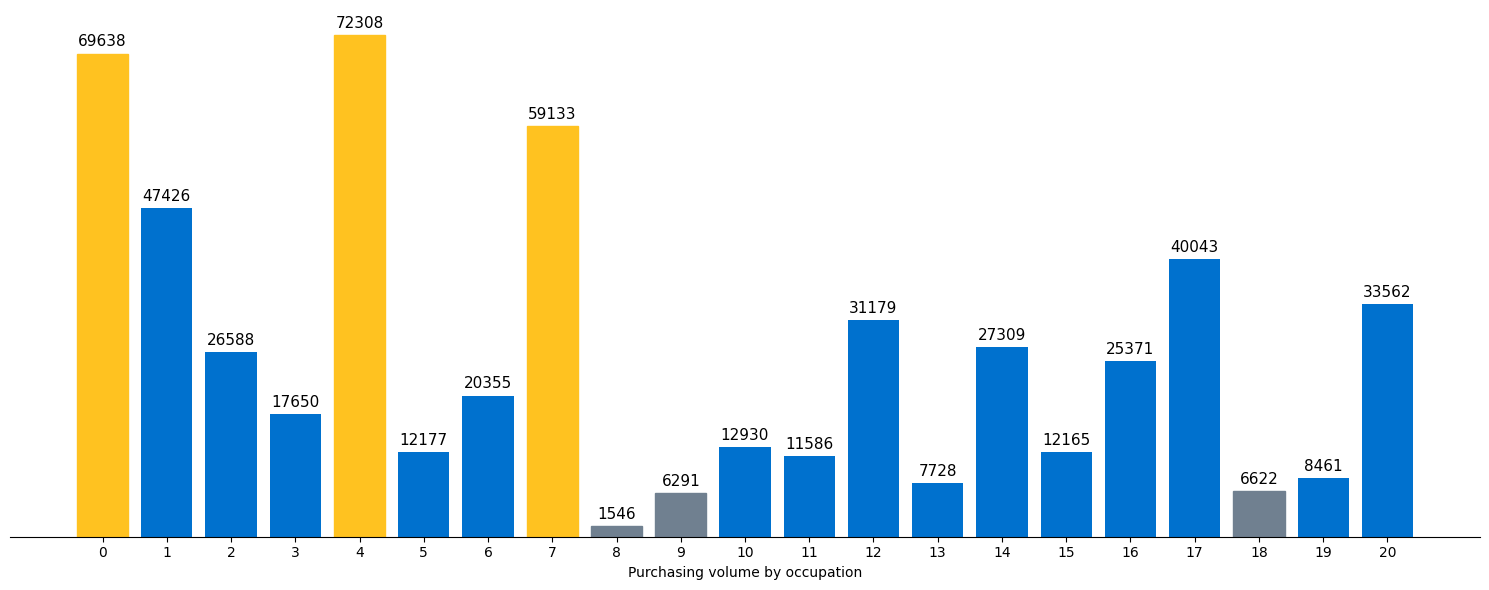

In [13]:
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'
Grey = '#708090'

plt.figure(figsize = (15, 6))
ax = plt.gca()
bars = plt.bar(walmart['Occupation'].value_counts().index, walmart['Occupation'].value_counts().values, color = True_Blue)
ax.get_yaxis().set_visible(False)
ax.bar_label(ax.containers[0], padding=3, fontsize=11)
plt.title('')
plt.xlabel('Purchasing volume by occupation')
plt.ylabel('purchase_amount')
plt.xticks(walmart['Occupation'].value_counts().index.astype(int))

top_3_indices = np.argsort(walmart['Occupation'].value_counts().values)[-3:]
for idx in top_3_indices:
    bars[idx].set_color(Spark_Yellow)

bottom_3_indices = np.argsort(walmart['Occupation'].value_counts().values)[:3:]
for idx in bottom_3_indices:
    bars[idx].set_color(Grey)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
city = walmart['City_Category'].value_counts().sort_index()

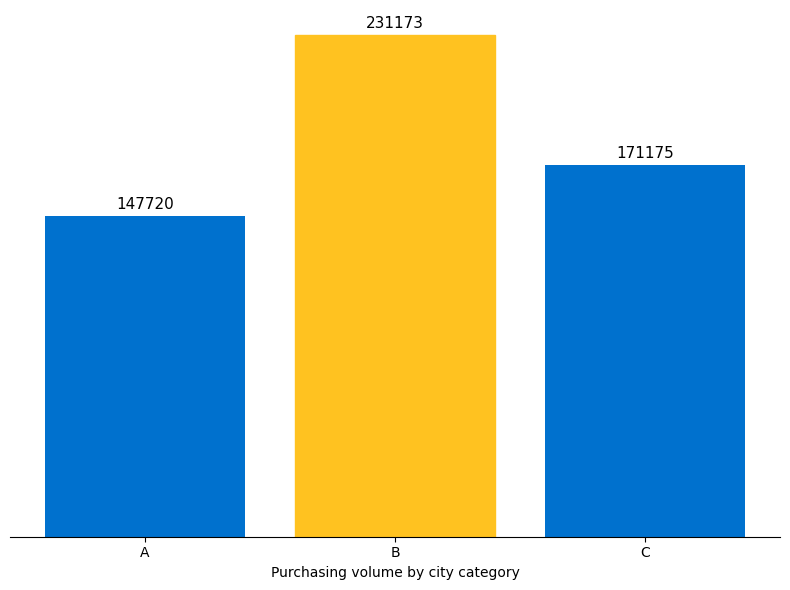

In [15]:
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'

plt.figure(figsize = (8, 6))
ax = plt.gca()
bars = plt.bar(city.index, city.values, color = True_Blue)
plt.xlabel('Purchasing volume by city category')
ax.get_yaxis().set_visible(False)
ax.bar_label(ax.containers[0], padding = 3, fontsize = 11)
plt.xticks(rotation = 0)

top_1_indices = np.argsort(city.values)[-1:]
for idx in top_1_indices:
    bars[idx].set_color(Spark_Yellow)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

In [16]:
walmart['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

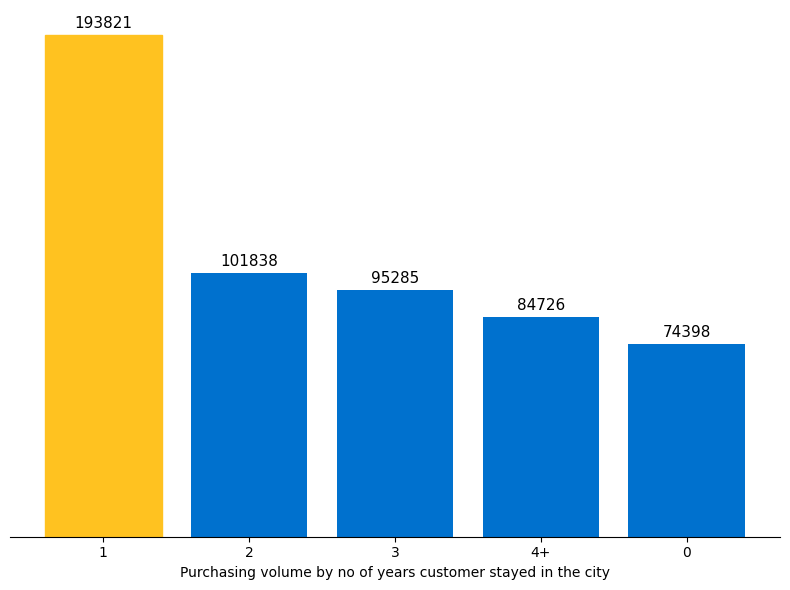

In [17]:
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'

plt.figure(figsize = (8, 6))
ax = plt.gca()
bars = plt.bar(walmart['Stay_In_Current_City_Years'].value_counts().index, walmart['Stay_In_Current_City_Years'].value_counts().values, color = True_Blue)
plt.xlabel('Purchasing volume by no of years customer stayed in the city')
ax.get_yaxis().set_visible(False)
ax.bar_label(ax.containers[0], padding = 3, fontsize = 11)

top_1_indices = np.argsort(walmart['Stay_In_Current_City_Years'].value_counts().values)[-1:]
for idx in top_1_indices:
    bars[idx].set_color(Spark_Yellow)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

In [18]:
marital_status = walmart['Marital_Status'].value_counts()
marital_status.index

Index([0, 1], dtype='object', name='Marital_Status')

In [19]:
marital_status.values

array([324731, 225337])

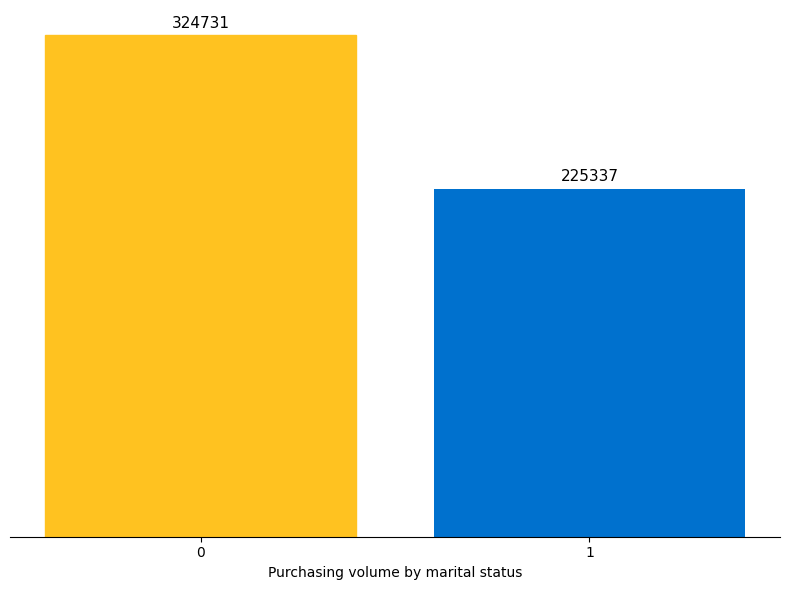

In [20]:
from matplotlib import legend
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'

plt.figure(figsize = (8, 6))
ax = plt.gca()
bars = plt.bar(marital_status.index, marital_status.values, color = True_Blue)
plt.xlabel('Purchasing volume by marital status')
plt.xticks(marital_status.index.astype(int))
ax.get_yaxis().set_visible(False)
ax.bar_label(ax.containers[0], padding = 3, fontsize = 11)

plt.xticks(rotation = 0)

top_1_indices = np.argsort(marital_status.values)[-1:]
for idx in top_1_indices:
    bars[idx].set_color(Spark_Yellow)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

In [21]:
walmart['Product_Category'].unique()

array([3, 1, 12, 8, 5, 4, 2, 6, 14, 11, 13, 15, 7, 16, 18, 10, 17, 9, 20,
       19], dtype=object)

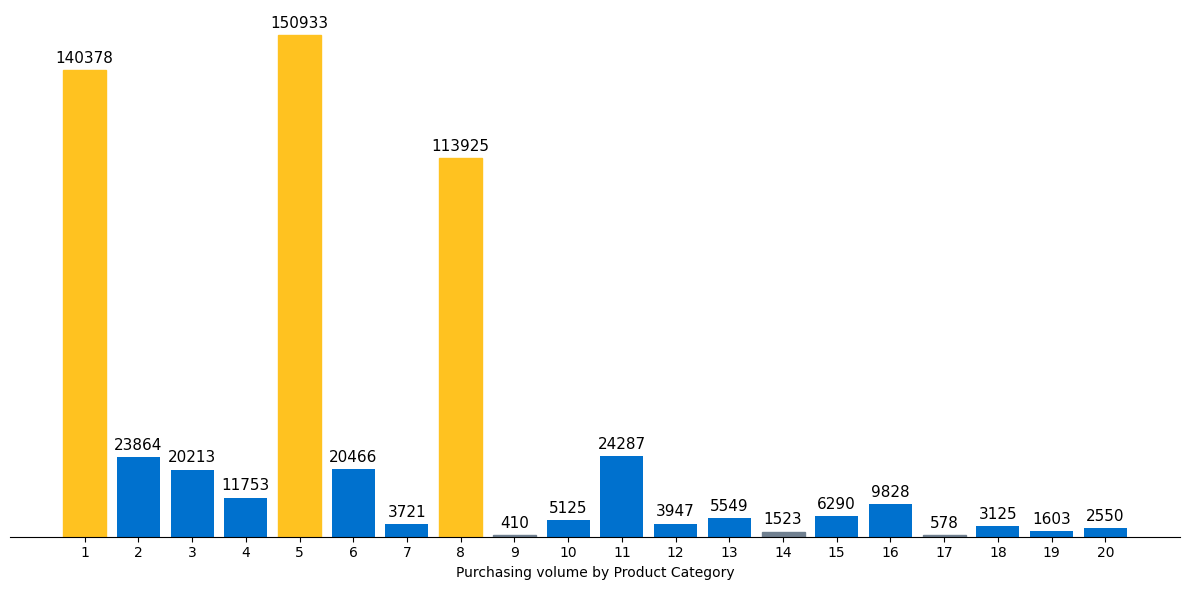

In [22]:
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'
Grey = '#708090'

prod_counts = walmart['Product_Category'].value_counts()

plt.figure(figsize = (12, 6))
ax = plt.gca()
bars = plt.bar(prod_counts.index, prod_counts.values, color = True_Blue)
ax.bar_label(ax.containers[0], padding = 3, fontsize = 11)
ax.get_yaxis().set_visible(False)

plt.xticks(prod_counts.index.astype(int))

plt.xlabel('Purchasing volume by Product Category')

top_3_indices = np.argsort(walmart['Product_Category'].value_counts().values)[-3:]
for idx in top_3_indices:
    bars[idx].set_color(Spark_Yellow)

bottom_3_indices = np.argsort(walmart['Product_Category'].value_counts().values)[:3:]
for idx in bottom_3_indices:
    bars[idx].set_color(Grey)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

---

# **EDA Conclusion:**

---

---

# **Walmart wants to understand if the spending habits differ in:**

---

  * **male and female customers**
  * **married and single customers**
  * **different age groups**
  * **different city category**
  

---

# **Analysis based on gender**

---

```
Let's seperate the dataset based on gender
```



In [23]:
customer_distribution_by_gender = walmart['User_ID'].groupby(walmart['Gender']).count().reset_index()
total_female_customers = customer_distribution_by_gender[customer_distribution_by_gender['Gender']=='F']
total_male_customers = customer_distribution_by_gender[customer_distribution_by_gender['Gender']=='M']

In [24]:
customer_distribution_by_gender

,Gender,User_ID
0,F,135809
1,M,414259


In [25]:
unique_customers = walmart['User_ID'].groupby(walmart['Gender']).nunique().reset_index('Gender')
unique_female_customers = unique_customers[unique_customers['Gender']=='F']
unique_male_customers = unique_customers[unique_customers['Gender']=='M']


In [26]:
unique_customers.sum()

,0
Gender,FM
User_ID,5891


In [27]:
unique_customers

,Gender,User_ID
0,F,1666
1,M,4225


In [28]:
avg_purchase_per_customer = walmart['User_ID'].count()/walmart['User_ID'].nunique()
avg_purchase_per_customer

np.float64(93.37429977932439)

In [29]:
avg_purchage_female = total_female_customers['User_ID'].iloc[0] / unique_female_customers['User_ID'].iloc[0]
avg_purchage_female

np.float64(81.51800720288115)

In [30]:
avg_purchage_male = total_male_customers['User_ID'].iloc[0] / unique_male_customers['User_ID'].iloc[0]
avg_purchage_male

np.float64(98.0494674556213)

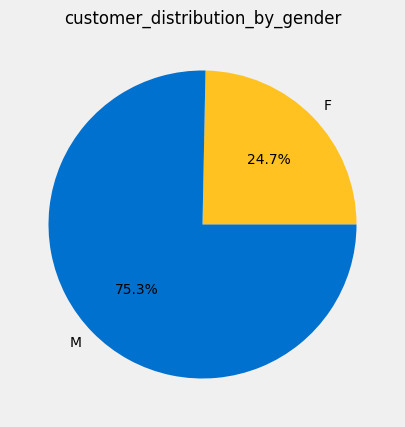

In [31]:
plt.figure(figsize=(10,5), facecolor='#F0F0F0')
plt.pie(x=customer_distribution_by_gender['User_ID'], labels=customer_distribution_by_gender['Gender'], colors=['#FFC220', '#0071CE'], autopct='%1.1f%%')
plt.title('customer_distribution_by_gender')
plt.show()

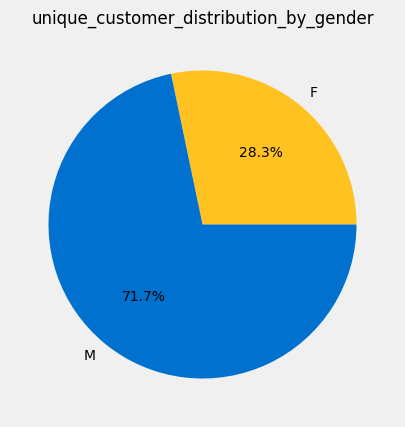

In [32]:
plt.figure(figsize=(10,5), facecolor='#F0F0F0')
plt.pie(x=unique_customers['User_ID'], labels=unique_customers['Gender'], colors=['#FFC220', '#0071CE'], autopct='%1.1f%%')
plt.title('unique_customer_distribution_by_gender')
plt.show()

In [33]:
walmart['Purchase'].sum()

np.int64(5095812742)

In [34]:
walmart[walmart['Gender']=='F']['Purchase'].mean()

np.float64(8734.565765155476)

In [35]:
walmart[walmart['Gender']=='M']['Purchase'].mean()

np.float64(9437.526040472265)

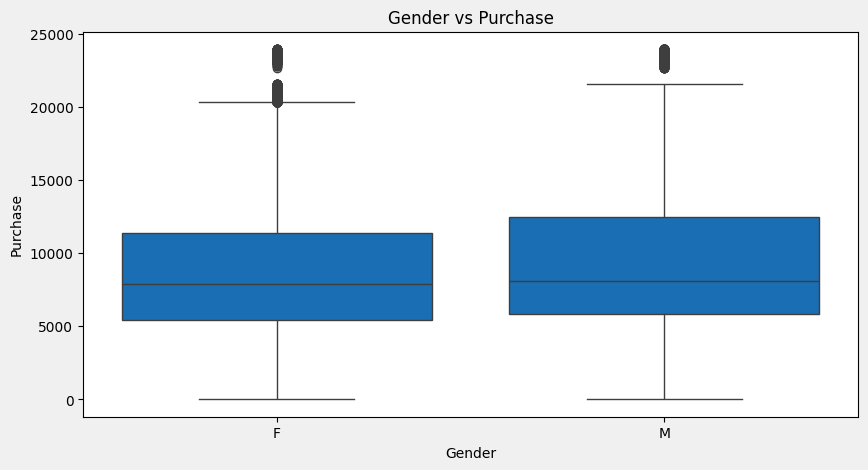

In [36]:
plt.figure(figsize=(10,5), facecolor='#F0F0F0')
sns.boxplot(x=walmart['Gender'], y=walmart['Purchase'], color='#0071CE')
plt.xlabel('Gender')
plt.ylabel('Purchase')
plt.title('Gender vs Purchase')
plt.show()

In [37]:
female_customers = walmart[walmart['Gender'] == 'F']
female_customers

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
14,1000006,P00231342,F,51-55,9,A,1,0,5,5378
...,...,...,...,...,...,...,...,...,...,...
550061,1006029,P00372445,F,26-35,1,C,1,1,20,599
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365


In [38]:
male_customers = walmart[walmart['Gender'] == 'M']
male_customers

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
5,1000003,P00193542,M,26-35,15,A,3,0,1,15227
6,1000004,P00184942,M,46-50,7,B,2,1,1,19215
7,1000004,P00346142,M,46-50,7,B,2,1,1,15854
8,1000004,P0097242,M,46-50,7,B,2,1,1,15686
...,...,...,...,...,...,...,...,...,...,...
550057,1006023,P00370853,M,26-35,0,C,2,1,19,61
550058,1006024,P00372445,M,26-35,12,A,0,1,20,121
550060,1006026,P00371644,M,36-45,6,C,1,1,20,494
550062,1006032,P00372445,M,46-50,7,A,3,0,20,473


### Average purchase amount per transaction by Gender

In [39]:
avg_female_purchase = female_customers['Purchase'].mean()
avg_male_purchase = male_customers['Purchase'].mean()

print(f"Average purchase amount for female customers: {avg_female_purchase:.2f}")
print(f"Average purchase amount for male customers: {avg_male_purchase:.2f}")

Average purchase amount for female customers: 8734.57
Average purchase amount for male customers: 9437.53


Use the sample average to find out an interval within which the population average will lie. Using the sample of female customers you will calculate the interval within which the average spending of 50 million male and female customers may lie.

**Confidence Interval for Average Purchase by Gender**

Now, let's calculate the 95% confidence interval for the average purchase amount for both female and male customers. This will give us a range within which the true population mean is likely to fall.

In [40]:
import scipy.stats as st

female_mean = female_customers['Purchase'].mean()
female_std = female_customers['Purchase'].std()
female_n = len(female_customers)
female_ci = st.norm.interval(confidence = 0.95, loc = female_mean, scale = female_std/np.sqrt(female_n))

print(f"95% confidence interval for female purchases: {female_ci}")

95% confidence interval for female purchases: (np.float64(8709.21154714068), np.float64(8759.919983170272))


**95% confidence interval for female purchases: 8709 to 8759**

In [41]:
male_mean = male_customers['Purchase'].mean()
male_std = male_customers['Purchase'].std()
male_n = len(male_customers)
male_ci = st.norm.interval(confidence = 0.95, loc = male_mean, scale = male_std/np.sqrt(male_n))

print(f"95% confidence interval for male purchases: {male_ci}")

95% confidence interval for male purchases: (np.float64(9422.01944736257), np.float64(9453.032633581959))


**95% confidence interval for male purchases: 9422 to 9453**

### Conclusion on Gender-Based Spending

The average purchase amount for male customers is higher than that for female customers. The confidence intervals also indicate that the average spending of males is consistently higher than females, with no overlap between their 95% confidence intervals. This suggests a statistically significant difference in spending habits, where male customers tend to spend more per transaction on Black Friday compared to female customers.

---

Use the Central limit theorem to compute the interval. Change the sample size to observe the distribution of the mean of the expenses by female and male customers.

The interval that you calculated is called Confidence Interval. The width of the interval is mostly decided by the business: Typically 90%, 95%, or 99%. Play around with the width parameter and report the observations.
conclude the results and check if the confidence intervals of average male and female spends are overlapping or not overlapping. How can Walmart leverage this conclusion to make changes or improvements?

---

In [101]:
import scipy.stats as stats
sample_sizes = [100000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for gender in ['F']:

        gender_pop = walmart[walmart['Gender'] == gender]['Purchase']

        sample = gender_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        sem = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * sem

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Gender': gender,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(sem, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n) Gender Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         100000      F              90%      8766.33         15.1745      8741.37      8791.29           49.92
         100000      F              95%      8766.33         15.1745      8736.59      8796.07           59.48
         100000      F              99%      8766.33         15.1745      8727.25      8805.42           78.17


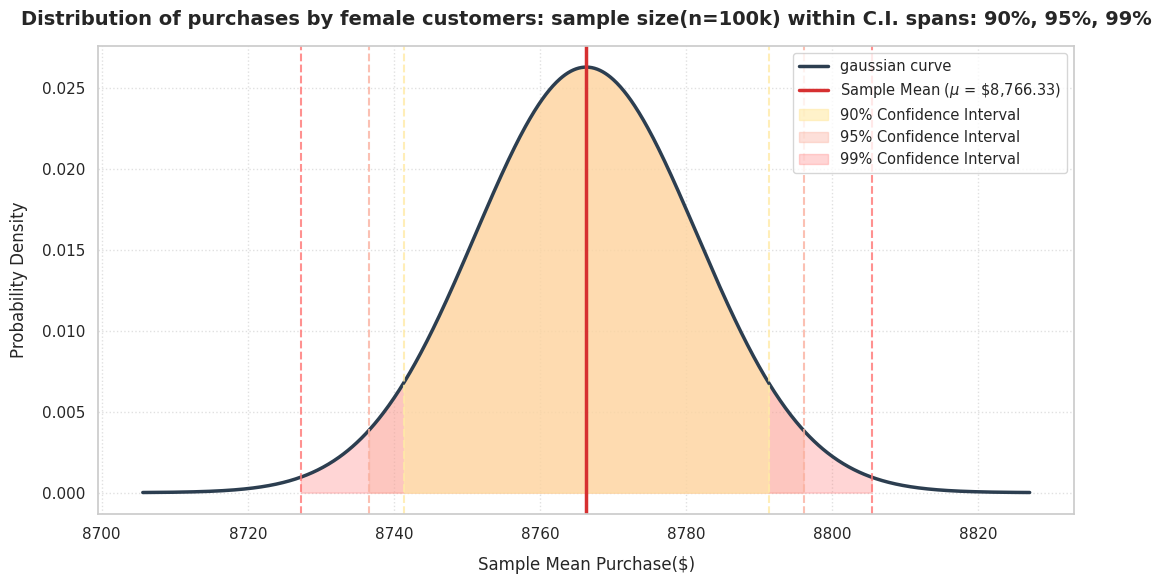

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 100000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Gender'] == 'F')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Gender = 'F'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * sem, sample_mean + 4 * sem, 1000)
    y = stats.norm.pdf(x, sample_mean, sem)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#ff7675', '#fab1a0', '#ffeaa7']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * sem
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, sem)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of purchases by female customers: sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [103]:
import scipy.stats as stats
sample_sizes = [300000] # Include all desired sample sizes here
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for gender in ['F']:

        gender_pop = walmart[walmart['Gender'] == gender]['Purchase']

        sample = gender_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        sem = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * sem

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Gender': gender,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(sem, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n) Gender Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         300000      F              90%      8740.92          8.7105      8726.59      8755.25           28.65
         300000      F              95%      8740.92          8.7105      8723.85      8757.99           34.14
         300000      F              99%      8740.92          8.7105      8718.49      8763.36           44.87


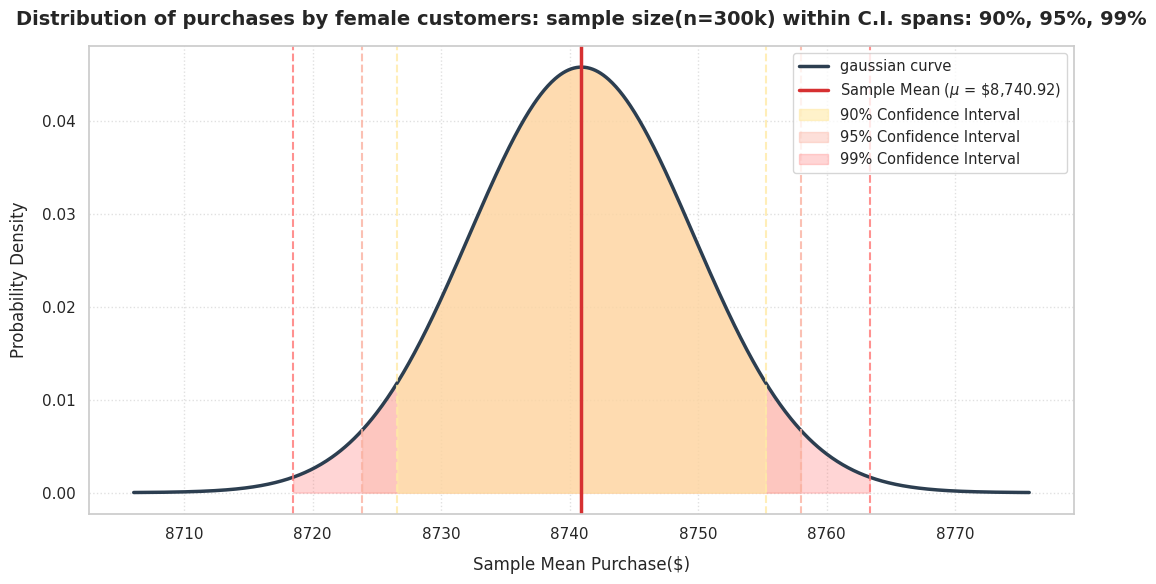

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 300000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Gender'] == 'F')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Gender = 'F'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * sem, sample_mean + 4 * sem, 1000)
    y = stats.norm.pdf(x, sample_mean, sem)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#ff7675', '#fab1a0', '#ffeaa7']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * sem
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, sem)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of purchases by female customers: sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [105]:
import scipy.stats as stats
sample_sizes = [500000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for gender in ['F']:

        gender_pop = walmart[walmart['Gender'] == gender]['Purchase']

        sample = gender_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        sem = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * sem

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Gender': gender,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(sem, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n) Gender Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         500000      F              90%      8740.56          6.7485      8729.46      8751.66           22.20
         500000      F              95%      8740.56          6.7485      8727.34      8753.79           26.45
         500000      F              99%      8740.56          6.7485      8723.18      8757.94           34.77


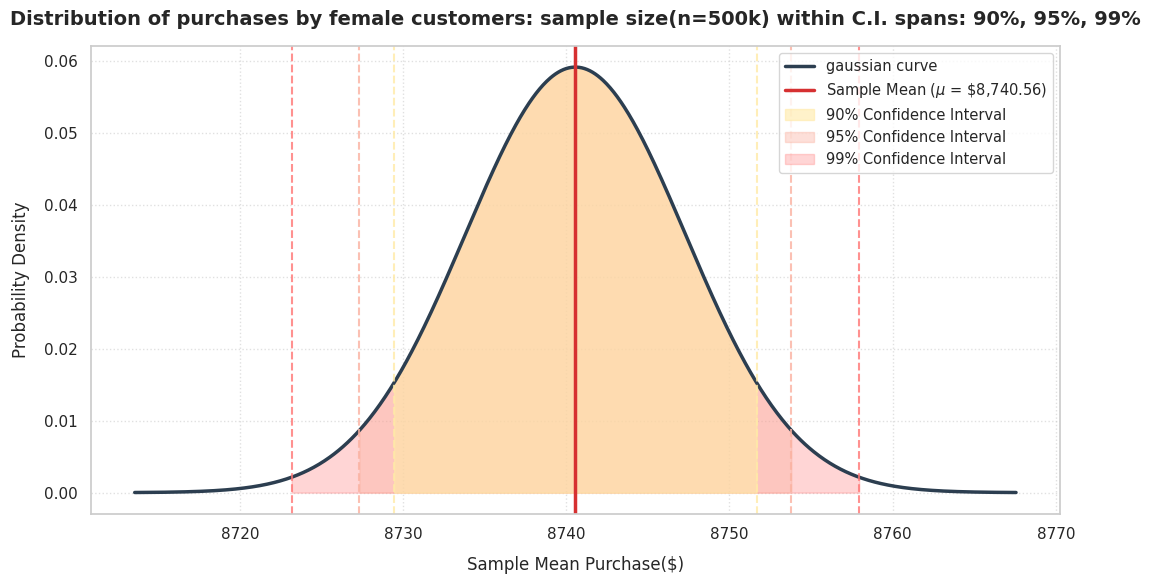

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 500000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Gender'] == 'F')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Gender = 'F'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * sem, sample_mean + 4 * sem, 1000)
    y = stats.norm.pdf(x, sample_mean, sem)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#ff7675', '#fab1a0', '#ffeaa7']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * sem
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, sem)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of purchases by female customers: sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [117]:
import scipy.stats as stats
sample_sizes = [100000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for gender in ['M']:

        gender_pop = walmart[walmart['Gender'] == gender]['Purchase']

        sample = gender_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        sem = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * sem

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Gender': gender,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(sem, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n) Gender Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         100000      M              90%      9455.52         16.0955      9429.04      9481.99           52.95
         100000      M              95%      9455.52         16.0955      9423.97      9487.06           63.09
         100000      M              99%      9455.52         16.0955      9414.06      9496.98           82.92


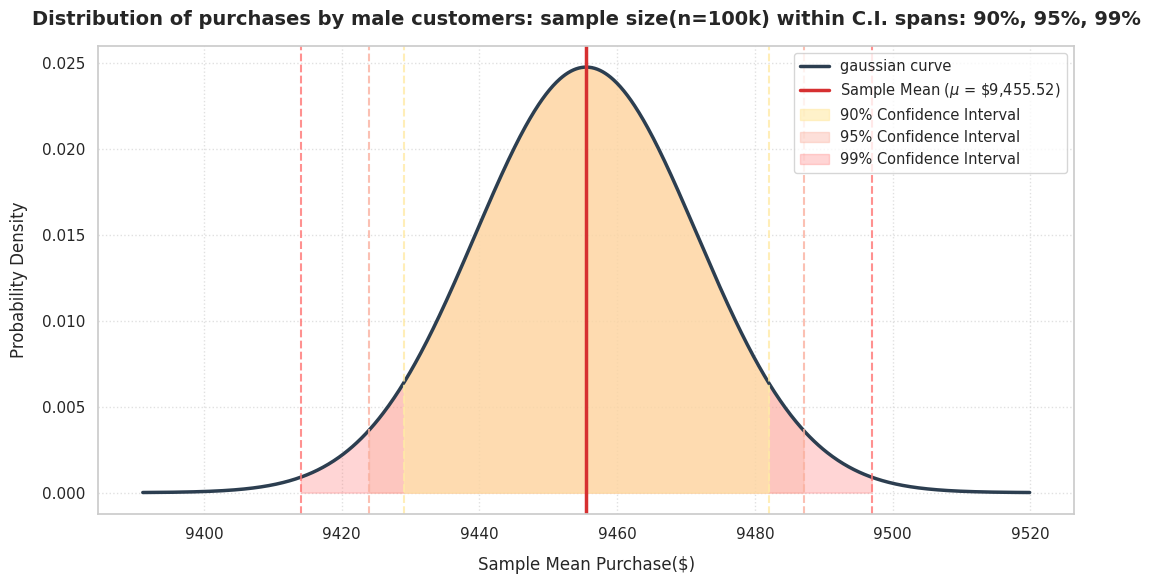

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 100000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Gender'] == 'M')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Gender = 'M'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * sem, sample_mean + 4 * sem, 1000)
    y = stats.norm.pdf(x, sample_mean, sem)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#ff7675', '#fab1a0', '#ffeaa7']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * sem
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, sem)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of purchases by male customers: sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [119]:
import scipy.stats as stats
sample_sizes = [300000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for gender in ['M']:

        gender_pop = walmart[walmart['Gender'] == gender]['Purchase']

        sample = gender_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        sem = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * sem

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Gender': gender,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(sem, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n) Gender Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         300000      M              90%      9443.21          9.2783      9427.95      9458.47           30.52
         300000      M              95%      9443.21          9.2783      9425.03      9461.40           36.37
         300000      M              99%      9443.21          9.2783      9419.31      9467.11           47.80


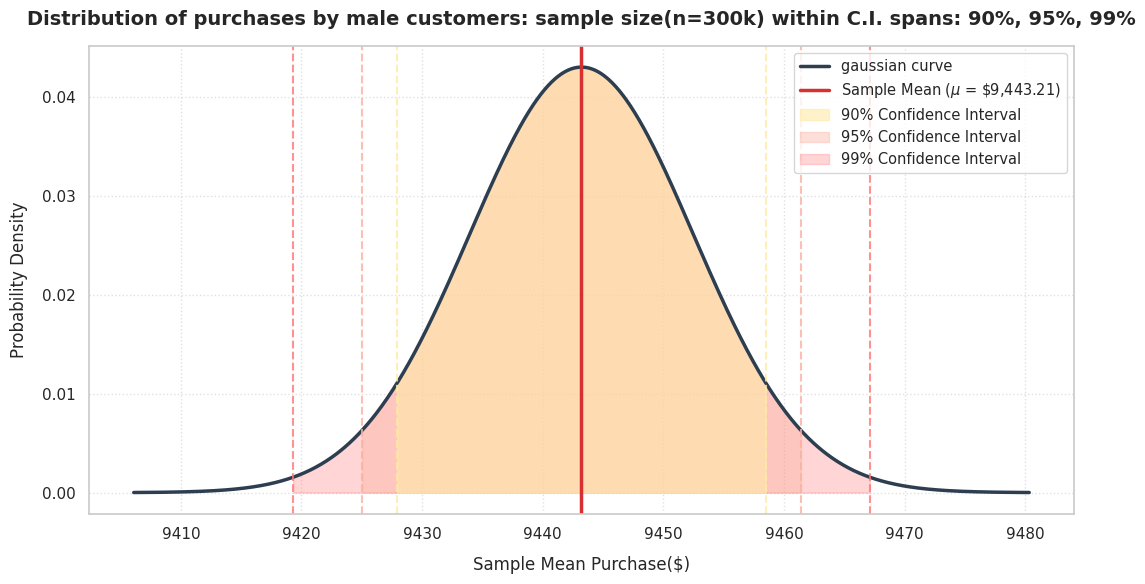

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 300000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Gender'] == 'M')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Gender = 'M'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * sem, sample_mean + 4 * sem, 1000)
    y = stats.norm.pdf(x, sample_mean, sem)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#ff7675', '#fab1a0', '#ffeaa7']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * sem
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, sem)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of purchases by male customers: sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [121]:
import scipy.stats as stats
sample_sizes = [500000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for gender in ['M']:

        gender_pop = walmart[walmart['Gender'] == gender]['Purchase']

        sample = gender_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        sem = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * sem

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Gender': gender,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(sem, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n) Gender Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         500000      M              90%      9441.79          7.1965      9429.96      9453.63           23.67
         500000      M              95%      9441.79          7.1965      9427.69      9455.90           28.21
         500000      M              99%      9441.79          7.1965      9423.26      9460.33           37.07


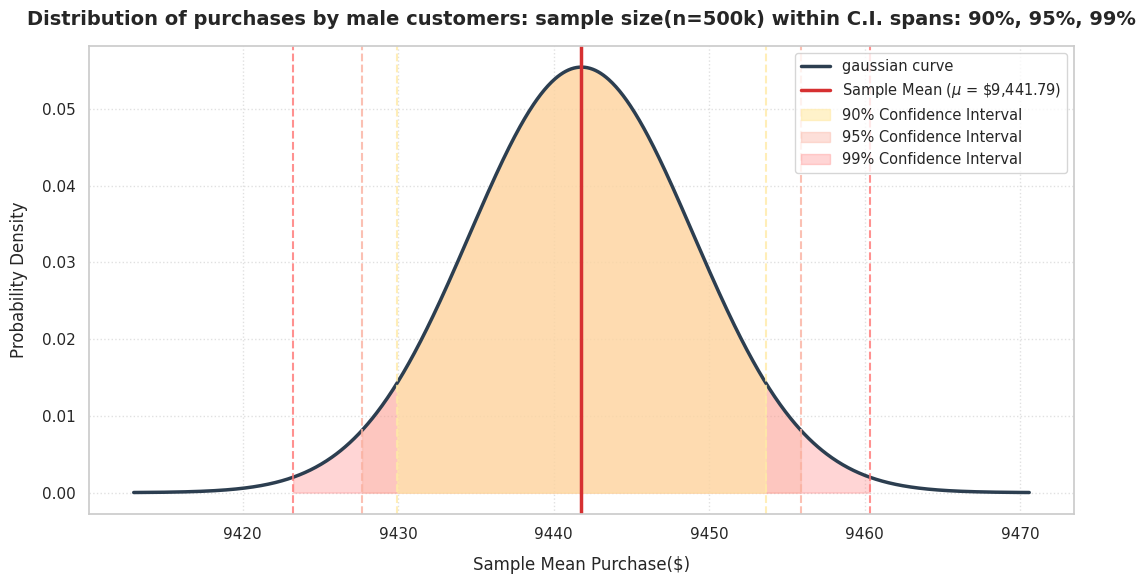

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 500000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Gender'] == 'M')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Gender = 'M'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * sem, sample_mean + 4 * sem, 1000)
    y = stats.norm.pdf(x, sample_mean, sem)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#ff7675', '#fab1a0', '#ffeaa7']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * sem
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, sem)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of purchases by male customers: sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

Use the sample average to find out an interval within which the population average will lie.

Using the sample of female customers you will calculate the interval within which the average spending of 50 million male and female customers may lie.

---

# **Conclusion of gender based analysis:**

---

* **Total customers : 550k**
  * **135809 (F)**
  * **414259 (M)**

* **Unique customers : 5891**
  * **1666 (F)**
  * **4225 (M)**
  
* **The average number of purchases per customer : 93**
  * **Female : 81.52**
  * **Male : 98.05**

* **Females contribute to 1/4 of total transactions**
* **Males contribute to 3/4 of the total transactions.**

* **71% of men contributes to 75% of revenue**

* **28% of women contributes to 25% of revenue**

---

# **Analysis based on marital status**

---

---

# **Conclusion of marital status based analysis:**

---

---

# **Analysis based on age groups**

---

---

# **Final analysis**

---


---
# **Recommendations:**

---